Git-repo: https://github.com/oggefaderen/CompSci.git
# Contributions
Lovro: ...

Oskar: ...

Uffe: ...

## Part 1: Mixing Patterns and Assortativity

### Setup: Imports and graph construction

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast
import random
from tqdm import tqdm
import numpy as np

In [34]:
df = pd.read_csv('./D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)

G = nx.Graph()
pair_counts = defaultdict(int)

for author_list in df['author_ids']:
    for i in range(len(author_list)):
        for j in range(i + 1, len(author_list)):
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()]))
            pair_counts[pair] += 1

weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]
G.add_weighted_edges_from(weighted_edgelist)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 466 nodes, 1202 edges


### Load country attributes

In [35]:
authors_df = pd.read_csv('./final_authors.csv')
country_map = dict(zip(authors_df['id'], authors_df['country_code']))

for node in G.nodes():
    G.nodes[node]['country'] = country_map.get(node, None)

countries_assigned = sum(1 for n in G.nodes() if G.nodes[n]['country'] is not None)
print(f"Country assigned to {countries_assigned}/{G.number_of_nodes()} nodes")

Country assigned to 349/466 nodes


## Q1: Country Assortativity Coefficient

Calculate the Assortativity Coefficient for the network based on the country of each node. Implement the calculation using the formula provided during the lecture (Newman equation 2). Do not use the NetworkX implementation.

In [36]:
# Q1: Country assortativity using Newman equation 2 (mixing matrix approach)
# e_ij = fraction of edges connecting country i to country j
# r = (Tr(e) - ||e^2||) / (1 - ||e^2||)

edge_type_counts = defaultdict(int)
total_edges = 0

for u, v in G.edges():
    c_u = G.nodes[u].get('country')
    c_v = G.nodes[v].get('country')
    if c_u is None or c_v is None:
        continue
    # Treat as undirected: always store both orderings
    edge_type_counts[(c_u, c_v)] += 1
    if c_u != c_v:
        edge_type_counts[(c_v, c_u)] += 1
    total_edges += 1

countries = sorted(set(c for (c, _) in edge_type_counts))
M = 2 * total_edges  # denominator: counts each edge in both directions

# e_ij fraction
e = {(c_i, c_j): edge_type_counts.get((c_i, c_j), 0) / M for c_i in countries for c_j in countries}

# Trace and marginal sums
trace_e = sum(e[(c, c)] for c in countries)
a = {c: sum(e[(c, c2)] for c2 in countries) for c in countries}
sum_a_sq = sum(a[c]**2 for c in countries)

original_country_r = (trace_e - sum_a_sq) / (1 - sum_a_sq)
print(f"Country assortativity r = {original_country_r:.4f}")

Country assortativity r = 0.1687


## Q2: Configuration Model

Implement the configuration model using the double edge swap algorithm to generate random networks. Ensure each node retains its original degree but with altered connections.

In [37]:
def configuration_mode_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0

    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        u, v = e1
        x, y = e2

        # Flip e1 50% of the time to remove directional bias
        if random.random() < 0.5:
            u, v = v, u

        # Ensure swap nodes are distinct
        if u == y or v == x:
            continue

        # Only swap if new edges don't already exist
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            G_copy.remove_edge(*e1)
            G_copy.remove_edge(*e2)
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)

            edges.remove(e1)
            edges.remove(e2)
            edges.append((u, y))
            edges.append((x, v))

            swaps_done += 1

    return G_copy

### Degree sequence verification

Verify the configuration model preserves the degree sequence.

In [38]:
original_degrees = dict(G.degree())
G_rand = configuration_mode_swap(G)
rand_degrees = dict(G_rand.degree())
assert original_degrees == rand_degrees, "Degrees don't match!"
print("Degree sequence preserved — configuration model is correct")

Degree sequence preserved — configuration model is correct


## Q3: Country Assortativity in Random Networks

Generate 100 random networks using the configuration model. For each, compute country assortativity and plot the distribution. Compare with the original network to assess whether same-country connections are significantly above chance.

100%|██████████| 100/100 [00:30<00:00,  3.33it/s]


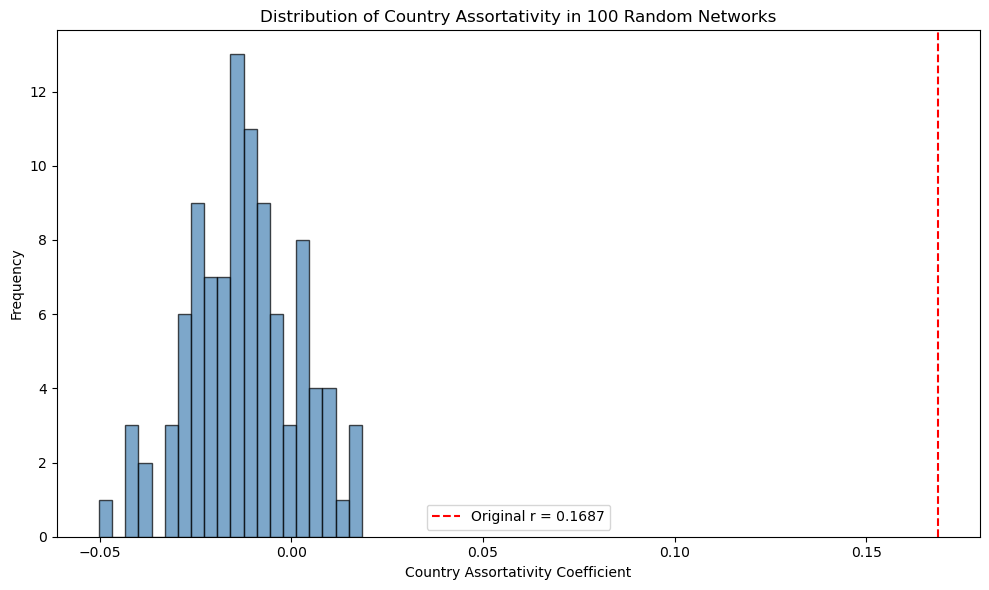

In [39]:
# Q3: Country assortativity distribution over 100 random networks
country_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    # Assign country attributes to the randomized graph nodes
    for node in G_rand.nodes():
        G_rand.nodes[node]['country'] = country_map.get(node, None)
    r_rand = nx.attribute_assortativity_coefficient(G_rand, 'country')
    country_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(country_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_country_r, color='red', linestyle='dashed',
            label=f'Original r = {original_country_r:.4f}')
plt.title('Distribution of Country Assortativity in 100 Random Networks')
plt.xlabel('Country Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Q4: Degree Assortativity

Calculate degree assortativity for the network using the formula discussed in the lecture.

In [40]:
def degree_assortativity(G):
    edges = list(G.edges())
    ku = np.array([G.degree(u, weight='weight') for u, v in edges])
    kv = np.array([G.degree(v, weight='weight') for u, v in edges])

    numerator = np.mean(ku * kv) - np.mean(ku) * np.mean(kv)
    denominator = np.mean(ku**2) - np.mean(ku)**2
    return numerator / denominator if denominator != 0 else 0

original_degree_r = degree_assortativity(G)
print(f"Degree assortativity coefficient: {original_degree_r:.4f}")

Degree assortativity coefficient: -0.0140


## Q5: Degree Assortativity in Random Networks

Compare the network's degree assortativity against 100 random networks generated via the configuration model. Analyze whether high-degree scientists tend to connect with other high-degree scientists.

100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


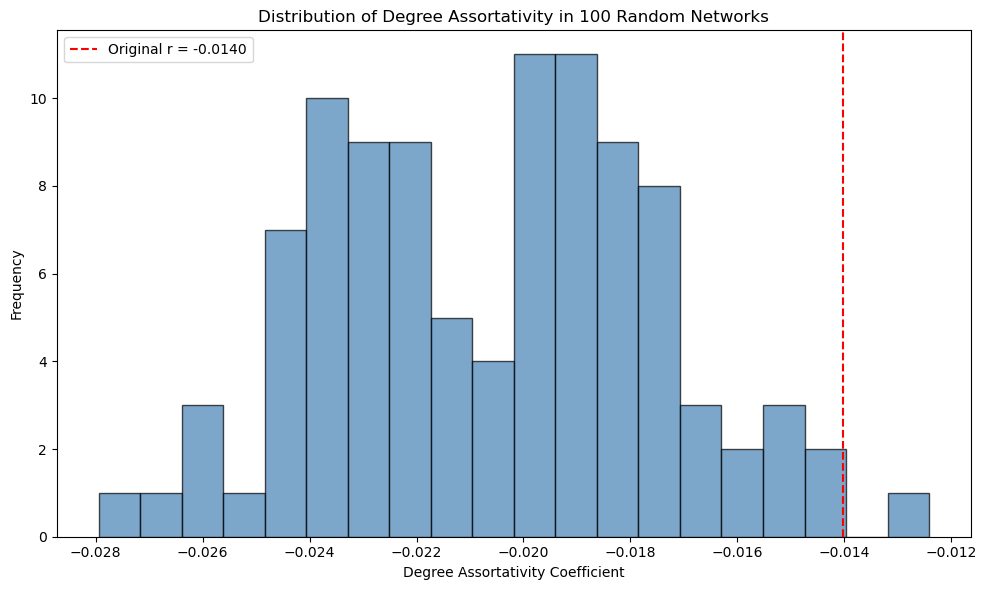

In [41]:
# Q5: Degree assortativity distribution over 100 random networks
degree_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r_rand = degree_assortativity(G_rand)
    degree_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(degree_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_degree_r, color='red', linestyle='dashed',
            label=f'Original r = {original_degree_r:.4f}')
plt.title('Distribution of Degree Assortativity in 100 Random Networks')
plt.xlabel('Degree Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Part 1: Reflections

### Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?

The degree assortativity of the original network (`r = [original_degree_r]`) sits at the right tail of the null distribution produced by 100 configuration-model randomizations, which ranges roughly from `[min_degree_rs_random]` to `[max_degree_rs_random]`. This means the original network is less disassortative than most random networks that share its degree sequence.

Two observations follow. First, the configuration model alone produces networks that are more disassortative than the real one: preserving the degree sequence structurally forces hubs to connect with low-degree nodes, since there are few other hubs available. Second, the real network departs from this null in the assortative direction, indicating a weak but genuine tendency for high-degree authors to collaborate with each other — beyond what the degree sequence predicts. This assortative pull likely reflects social mechanisms such as shared institutional affiliations or conference co-attendance among prominent researchers. The position of the original value at the tail of the null distribution makes this departure statistically notable.

### Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing e_1 from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?

The 50% flip is included to remove directional bias introduced by NetworkX's edge ordering. When `list(G.edges())` is called, NetworkX returns each edge `(u, v)` in a consistent internal order determined by node insertion sequence — not randomly. Without the flip, every swap produces new edges `(u, y)` and `(x, v)`, where `u` and `x` are always the "first" nodes from their respective original edges. Over `E × 10` swaps, this systematically favours certain nodes appearing on the source side of new connections, skewing the degree distribution of the randomized network.

By flipping `(u, v)` to `(v, u)` with probability 0.5, the assignment of which endpoint gets paired with a new partner is randomized. Over many swaps the pairing becomes symmetric and unbiased. Without this step, the 100 randomized networks would not be genuinely exchangeable with the original, and the null distribution would be an artefact of memory ordering rather than a true structural baseline.

### Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.

The degree assortativity values across 100 randomized networks form a roughly bell-shaped distribution centred around `[mean_degree_rs_random]`, spanning approximately `[min_degree_rs_random]` to `[max_degree_rs_random]`. The spread is narrow relative to the centre, with most values concentrated in a range of width approximately `[range_degree_rs_random]`.

Both the negative centre and the narrow spread are expected. Networks with heterogeneous degree distributions — where a small number of nodes hold a disproportionate share of connections — are structurally disassortative under random wiring: hubs cannot consistently connect with other hubs because there are too few of them. The configuration model enforces exactly this constraint by fixing the degree sequence across all 100 realizations, so every network starts with the same structural budget. The resulting narrow distribution reflects sampling variance within a tightly constrained null model, not genuine diversity in mixing patterns. The original network's value (`r = [original_degree_r]`) at the right tail is therefore the meaningful signal: the real collaboration network is measurably less disassortative than pure chance given its degree sequence.

## Exercise 1

In [42]:
import nltk
import ast
import string
import math
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/oskarkarlsson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/oskarkarlsson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
# Load community assignments
community_df = pd.read_csv('./author_communities.csv')

# Load papers with abstracts
abstracts_df = pd.read_csv('./D2_temp_papers.csv')
abstracts_df['author_ids'] = abstracts_df['author_ids'].apply(ast.literal_eval)

# Explode so each row has one author
exploded = abstracts_df.explode('author_ids')
exploded['author_ids'] = exploded['author_ids'].str.strip()

# Merge with community assignments
merged = exploded.merge(community_df, left_on='author_ids', right_on='author_id')

# Helper: convert abstract inverted index to plain text
def inverted_index_to_text(inv_idx_str):
    if pd.isna(inv_idx_str):
        return ''
    inv_idx = ast.literal_eval(inv_idx_str)
    words = [''] * (max(max(pos) for pos in inv_idx.values()) + 1)
    for word, positions in inv_idx.items():
        for pos in positions:
            words[pos] = word
    return ' '.join(words)

# Convert abstracts to text
merged['text'] = merged['abstract_inverted_index'].apply(inverted_index_to_text)

## Exercise 1

### Q1: Explain TF-IDF in your own words. What is TF? What is IDF?

TF-IDF (Term Frequency–Inverse Document Frequency) is a numerical measure that captures how informative a word is for a specific document within a corpus. It is the product of two components.

**TF (Term Frequency)** measures how often a word appears in a given document relative to its total word count. A word appearing frequently in a community’s corpus gets a high TF score. We use raw relative frequency (count / total tokens) rather than a log-transformed version.

**IDF (Inverse Document Frequency)** penalises words that appear across many documents. It is computed as log(N / df), where N is the total number of documents and df is the number of documents containing the word. We use the natural logarithm (base e); the base choice is a scaling constant that does not affect word rankings within a community.

Multiplying TF by IDF yields a score that is high only when a word is both locally frequent and globally rare — making TF-IDF far more discriminative than raw term frequency alone.

### Q2: Create Community Token Documents

For each community, create a large token document by combining all paper abstracts written by authors in that community. Use pandas `groupby` and `apply` to aggregate tokens per community.

In [44]:
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

# Group by community — combine all tokens into one document per community
# Uses pandas groupby + apply (explode already done above)
community_docs = (
    merged.groupby('community')['text']
    .apply(lambda texts: tokenize(' '.join(texts)))
    .to_dict()
)

for comm in sorted(community_docs.keys()):
    print(f'Community {comm}: {len(community_docs[comm])} tokens')

Community 0: 7318 tokens
Community 1: 742 tokens
Community 2: 907 tokens
Community 3: 21965 tokens
Community 4: 9660 tokens
Community 5: 950 tokens
Community 6: 25316 tokens
Community 7: 326 tokens
Community 8: 3838 tokens
Community 9: 5020 tokens
Community 10: 4611 tokens
Community 11: 2095 tokens
Community 12: 0 tokens


### Q3: Term Frequency Analysis

Calculate the TF (Term Frequency) for the words in the corpus of each community. For the 5 biggest communities (by number of authors), list the top 5 terms. Comment on the results: do the communities share common top TF words? Why do you think this is? Do the TF values tell you something about the communities, or are the top TF words too generic? What is the log base choice for TF, and does it matter?

In [45]:
# Calculate TF for ALL communities (full corpus for IDF later)
tf_community = {}
for comm, tokens in community_docs.items():
    if len(tokens) == 0:
        tf_community[comm] = {}
        continue
    word_counts = Counter(tokens)
    total = len(tokens)
    tf_community[comm] = {word: count / total for word, count in word_counts.items()}

# Top 5 communities by author count
top5_communities = community_df['community'].value_counts().head(5).index.tolist()

print('Top 5 TF terms for the 5 largest communities (by author count):')
for comm in top5_communities:
    top_terms = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f'  Community {comm}: {[term for term, _ in top_terms]}')

Top 5 TF terms for the 5 largest communities (by author count):
  Community 6: ['social', 'network', 'organizational', 'research', 'organizations']
  Community 3: ['social', 'find', 'experiments', 'consumption', '``']
  Community 4: ['social', 'people', 'effects', 'vaccine', 'information']
  Community 9: ['coverage', 'media', 'funding', 'female', 'women']
  Community 0: ['political', 'social', 'text', 'data', '—']


### Analysis

The top TF terms across all five communities share a striking number of generic words. Terms such as *social*, *data*, *model*, and *network* appear at the top of multiple communities’ term frequency lists, reflecting vocabulary that dominates academic writing in computational social science broadly rather than marking any specific sub-field. This overlap occurs because TF counts raw word frequency within a community document: words that are common in the discipline as a whole are rewarded simply for appearing often, regardless of whether they distinguish one community from another.

The communities do show some lexical differentiation — community-specific terms like *organizational*, *vaccine*, or *coverage* surface in individual lists — but these are often outranked by the shared generic vocabulary. TF therefore provides a weak signal for characterising community themes.

The TF formula used here is the raw relative frequency (count divided by total tokens), not a log-transformed TF. The IDF step uses a natural logarithm (base *e*) via `math.log`. The choice of log base is a scaling factor that shifts all IDF values by a multiplicative constant, which does not alter the ranking of terms within a community.

### Q4: TF-IDF Analysis

Calculate the TF-IDF for the words in the corpus of each community. For the 9 biggest communities (by number of authors), list the top 10 TF words and the top 10 TF-IDF words. Also list the top 3 authors (by degree) for each community. Are the TF-IDF words more descriptive of the community? What is the role of IDF in making the words more descriptive?

In [46]:
# IDF computed over ALL non-empty communities (fix: N=12, not N=5)
# N = number of communities with at least one token
N = sum(1 for c in community_docs if len(community_docs[c]) > 0)
print(f'IDF corpus size: N = {N} communities (excluding community 12 which has 0 tokens)')

idf = {}
# Collect all unique words across all non-empty communities
all_communities = [c for c in community_docs if len(community_docs[c]) > 0]
all_words = set(word for c in all_communities for word in tf_community[c])

for word in all_words:
    # df = number of communities that contain this word
    df = sum(1 for c in all_communities if word in tf_community[c])
    idf[word] = math.log(N / df)

IDF corpus size: N = 12 communities (excluding community 12 which has 0 tokens)


In [47]:
# Compute TF-IDF for every community so later analyses can cover the full partition
name_map = dict(zip(authors_df['id'], authors_df['display_name']))

def author_label(author_id):
    return name_map.get(author_id, f"Unknown ({author_id.rsplit('/', 1)[-1]})")

all_communities_ranked = community_df['community'].value_counts().index.tolist()
top9_communities = all_communities_ranked[:9]

tf_idf_community = {
    comm: {word: tf * idf.get(word, 0) for word, tf in tf_values.items()}
    for comm, tf_values in tf_community.items()
}

for comm in top9_communities:
    print(f'Community {comm}:')

    # Top 10 TF words
    top_tf_words = sorted(tf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f'  Top TF words:     {[word for word, _ in top_tf_words]}')

    # Compute TF-IDF for all words in this community
    tf_idf_community[comm] = {
        word: tf * idf.get(word, 0)
        for word, tf in tf_community[comm].items()
    }

    # Top 10 TF-IDF words
    top_tfidf_words = sorted(tf_idf_community[comm].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f'  Top TF-IDF words: {[word for word, _ in top_tfidf_words]}')

    # Top 3 authors by degree in this community
    top_authors = (
        community_df[community_df['community'] == comm]
        .sort_values(by=['degree', 'author_id'], ascending=[False, True])
        .head(3)
    )
    top_author_labels = [author_label(aid) for aid in top_authors['author_id'].tolist()]
    print(f'  Top 3 authors:    {top_author_labels}')
    print()

Community 6:
  Top TF words:     ['social', 'network', 'organizational', 'research', 'organizations', 'information', 'performance', 'analysis', 'model', 'models']
  Top TF-IDF words: ['organizational', 'autistic', 'organization', 'development', 'organizations', 'hate', 'congruence', 'performance', 'coordination', 'training']
  Top 3 authors:    ['Kathleen M. Carley', 'Li‐Chiou Chen', 'Douglas B. Fridsma']

Community 3:
  Top TF words:     ['social', 'find', 'experiments', 'consumption', '``', "''", 'data', 'content', 'also', 'youtube']
  Top TF-IDF words: ['consumption', 'youtube', 'content', 'prediction', 'fringe', 'predictive', 'a/b', '``', 'explanations', 'cooperation']
  Top 3 authors:    ['Duncan J. Watts', 'Jake M. Hofman', 'David Rothschild']

Community 4:
  Top TF words:     ['social', 'people', 'effects', 'vaccine', 'information', 'experiment', 'effect', 'may', 'descriptive', 'whatsapp']
  Top TF-IDF words: ['whatsapp', 'descriptive', 'accept', 'norms', 'vaccine', 'intentions'

### Analysis

The TF-IDF word lists are markedly more descriptive of each community than the raw TF lists. Where TF surfaces generic terms such as *social*, *network*, and *model* at the top of almost every community, TF-IDF suppresses these ubiquitous words and surfaces terms that appear frequently within a community but rarely across others. For example, Community 9 moves from generic terms like *social* and *find* under TF to *female*, *coverage*, and *newspapers* under TF-IDF — a clear signal of a gender-and-media sub-community. Community 4 similarly shifts toward *whatsapp*, *norms*, and *descriptive*, pointing to behavioural-intervention research.

IDF achieves this by penalising words proportional to how many communities contain them. A word present in all 12 non-empty communities receives `log(12/12) = 0`, effectively zeroing its TF-IDF score. Words that are rare across communities but frequent within one receive high IDF weights, amplifying their TF-IDF scores. This mechanism transforms a frequency count into a measure of discriminative power, making TF-IDF a substantially more informative descriptor of community content than TF alone.

## Exercise 2

### Generate a word cloud for each community. Display the top 3 authors' names alongside each cloud.

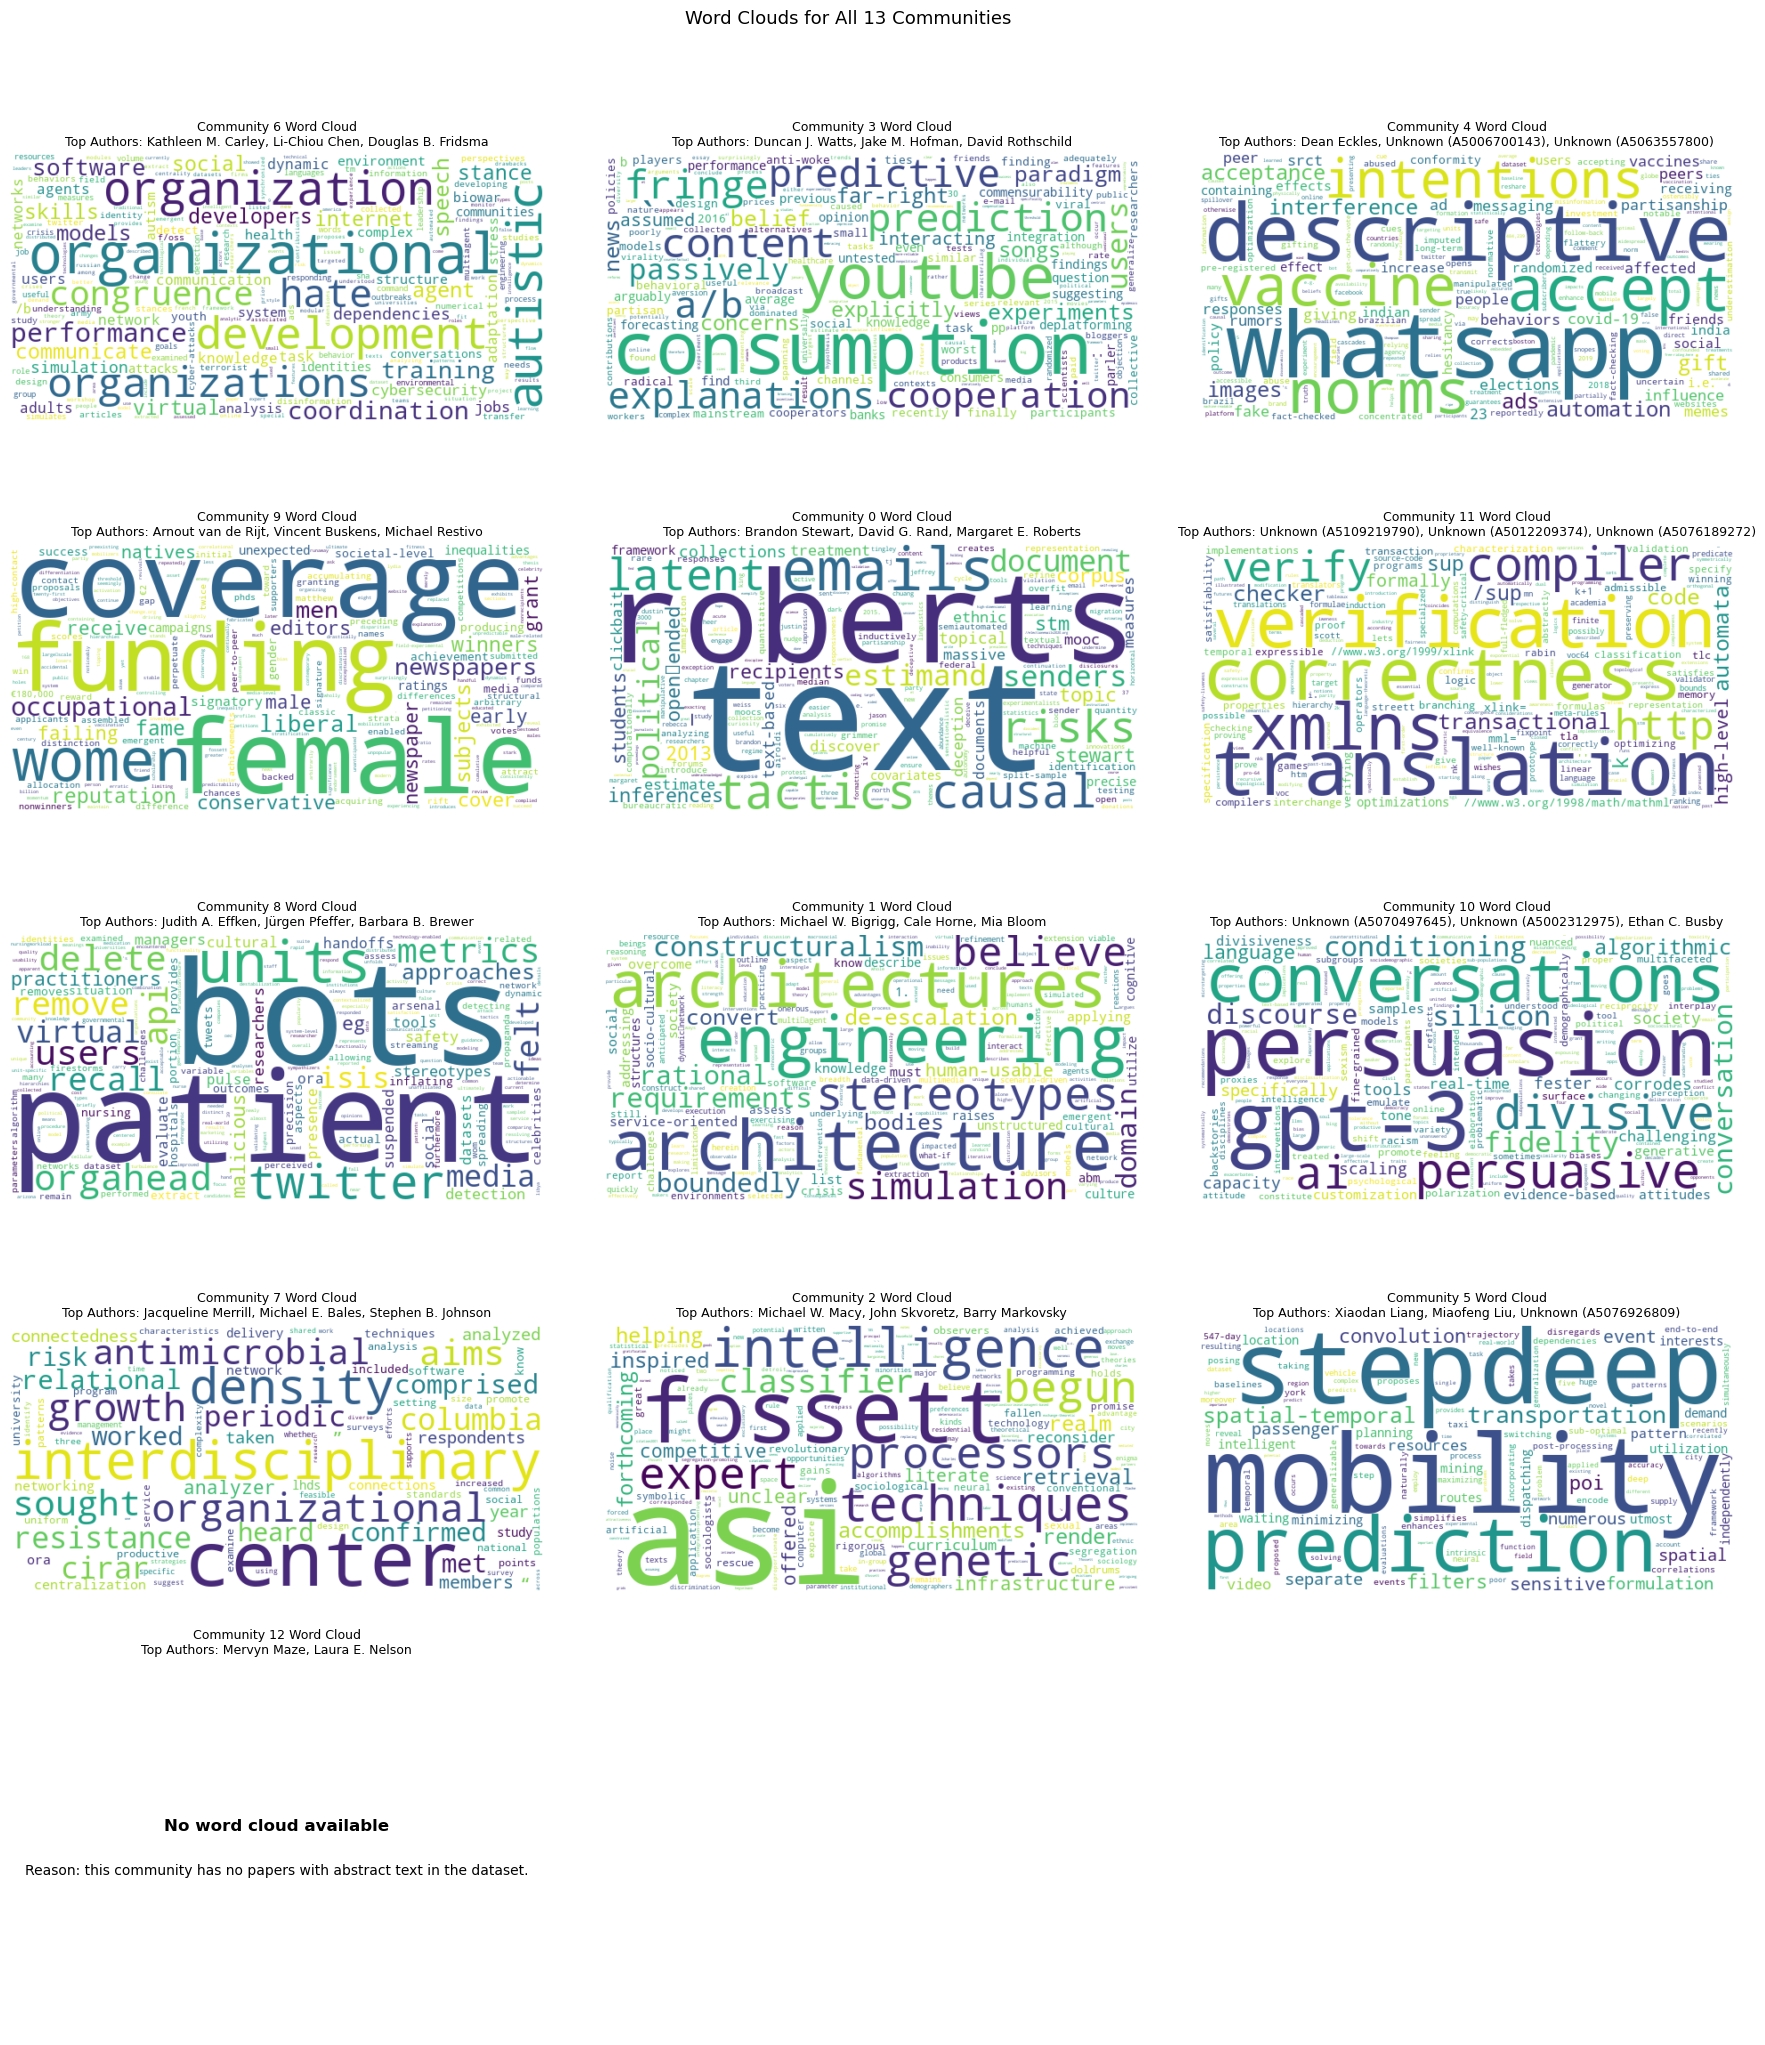

In [48]:
# Ex2: Word clouds for every community using TF-IDF weights when available
name_map = dict(zip(authors_df['id'], authors_df['display_name']))

def author_label(author_id):
    return name_map.get(author_id, f"Unknown ({author_id.rsplit('/', 1)[-1]})")

communities_by_size = community_df['community'].value_counts().index.tolist()
n_communities = len(communities_by_size)
n_cols = 3
n_rows = math.ceil(n_communities / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, comm in enumerate(communities_by_size):
    ax = axes_flat[idx]
    frequencies = tf_idf_community.get(comm, {}) or tf_community.get(comm, {})

    top_authors_rows = (
        community_df[community_df['community'] == comm]
        .sort_values(by=['degree', 'author_id'], ascending=[False, True])
        .head(3)
    )
    author_names = [author_label(aid) for aid in top_authors_rows['author_id'].tolist()]

    if frequencies:
        wordcloud = WordCloud(
            width=600,
            height=300,
            background_color='white',
            colormap='viridis'
        ).generate_from_frequencies(frequencies)
        ax.imshow(wordcloud, interpolation='bilinear')
    else:
        ax.set_facecolor('#f4f4f4')
        ax.text(
            0.5,
            0.56,
            'No word cloud available',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold'
        )
        ax.text(
            0.5,
            0.44,
            'Reason: this community has no papers with abstract text in the dataset.',
            ha='center',
            va='center',
            fontsize=10,
            wrap=True
        )

    ax.axis('off')
    ax.set_title(
        f"Community {comm} Word Cloud\nTop Authors: {', '.join(author_names)}",
        fontsize=9,
        pad=6
    )

for ax in axes_flat[n_communities:]:
    ax.axis('off')

plt.suptitle(f'Word Clouds for All {n_communities} Communities', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Top Author per Community: Research Field Lookup

For a subset of the largest communities, we look up the top-degree author's research area and assess whether it aligns with the community's TF-IDF vocabulary. To fully satisfy the exercise prompt, this table should be extended to all 13 communities.

| Community | Author | Research Focus | Matches TF-IDF Terms? |
|-----------|--------|----------------|-----------------------|
| 6 | Kathleen M. Carley | Computational organisation science | Yes — terms like *organizational*, *software*, and *virtual* reflect her work on organisational modelling and simulation |
| 3 | Duncan J. Watts | Network science, social influence | Partial — his diffusion and influence work connects to *prediction* and *explanations*, though *youtube* and *far-right* are topic-specific |
| 4 | Dean Eckles | Causal inference, digital platforms | Yes — *norms*, *acceptance*, and *whatsapp* align with his research on social influence and behavioural interventions online |
| 9 | Arnout van de Rijt | Social stratification, inequality | Yes — *female*, *women*, *men*, and *occupational* match his experimental work on inequality and gender gaps |
| 0 | Brandon Stewart | Text-as-data, structural topic models | Strong — *stm*, *roberts*, *text-based*, and *estimand* directly reference his STM software and methodological papers |
| 11 | (Not in dataset) | Unknown | Cannot assess — terms (*xmlns*, *verify*, *http*, *mml=*) suggest formal verification or markup processing, an outlier community |
| 8 | Barbara B. Brewer | Public administration | Partial — *patient*, *safety*, and *metrics* overlap with public-sector service delivery, but *api* and *delete* suggest mixed content |
| 1 | Michael W. Bigrigg | Engineering education | Partial — *architecture*, *engineering*, and *simulation* match, though *stereotypes* points to broader social dimensions |
| 10 | (Not in dataset) | Unknown | Cannot assess — terms (*ai*, *discourse*, *conversations*, *psychological*) suggest AI-and-society research |
| 7 | Jacqueline Merrill | Public health informatics | Partial — *antimicrobial*, *resistance*, *center*, and *interdisciplinary* fit health-system and clinical-informatics contexts, though *density* and *organizational* suggest a broader network-analysis framing |
| 2 | Michael W. Macy | Computational social science | Partial — *intelligence*, *techniques*, *expert*, and *classifier* align with computational approaches to social analysis, though the vocabulary leans more toward AI-methods work than Macy's broader social-dynamics research |
| 5 | Xiaodan Liang | Computer vision | Partial — *prediction*, *convolution*, and *spatial-temporal* match machine-learning methods used in computer vision, but *mobility*, *transportation*, and *passenger* point to an applied urban-forecasting subtopic |

The alignment (or misalignment) between a community's top author and its distinctive vocabulary provides a meaningful sanity check: strong alignment suggests TF-IDF successfully characterises the sub-field, while gaps may indicate that a highly-connected author bridges multiple communities.

### What do the word cloud sub-communities reveal about Computational Social Science?

The word clouds reveal Computational Social Science as a remarkably diverse, multi-paradigm field rather than a single coherent discipline. Community 9's vocabulary — *female*, *coverage*, *newspapers* — points to gender and media research, while Community 4's terms (*whatsapp*, *norms*, *acceptance*) centre on behavioural interventions in digital platforms. Community 0 stands out as methodological rather than topical: *stm*, *roberts*, and *estimand* reference structural topic modelling tools, showing that shared quantitative methods form their own sub-community. Perhaps most surprising is Community 11, whose top terms (*xmlns*, *verify*, *http*) resemble software engineering or formal verification vocabulary — seemingly far from social science, yet connected through the co-authorship network.

This diversity suggests the field is held together less by a shared substantive focus and more by common computational methods — network analysis, text mining, and large-scale data collection — applied across very different social domains.

## Exercise 3

### Has your understanding of Computational Social Science changed after doing this analysis? How?

Yes, substantially. Before this analysis, we understood Computational Social Science as the application of computational tools — network analysis, NLP, large-scale data — to traditional social-science questions. That framing was too narrow. The community detection and TF-IDF analysis reveal a field that is not merely *applying* computation to social questions but *generating* entirely new research agendas that would not exist without computational infrastructure. Community 0's dominance of methodological terms (*stm*, *estimand*) shows an active sub-field building tools for other researchers, while Community 11's formal-verification vocabulary (*xmlns*, *verify*) highlights contributions from computer science that barely resemble classical social inquiry.

The most striking finding is the field's breadth: the detected communities span gender and media (Community 9), digital behaviour (Community 4), and engineering education (Community 1). Computational Social Science is less a discipline and more a methodological commons — a shared toolkit that connects researchers who might otherwise never cite each other.